In [ ]:
import pandas as pd
from ultralytics import YOLO
import helpers

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
data_yaml_lwir = "path/to/data.yaml"
test_dataset="path/to/test"
test_images_path_lwir = test_dataset+"/images"

In [ ]:
epochs = 50
batch_size = 16
patience = 10
lr0=0.001
# weight_decay=0.001
# momentum=0.937
optimizer='AdamW'
# save_dir_lwir='path/to/savedir'

In [7]:
model = YOLO("yolo11n.pt")
history = model.train(data=data_yaml_lwir, epochs=epochs, batch=batch_size, imgsz=640, pretrained=True, save=True, save_period=10,
                      patience=patience,
                      # hsv_h=0.0, hsv_s=0.0, hsv_v=0.4,
                      # warmup_epochs=5.0,
                      # shear = 1.0,
                      # scale = 0.3,
                      # degrees=5.0,
                      # perspective = 0.0001,
                      # optimizer=optimize
                      )

Ultralytics 8.3.198 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12.0

In [8]:
model.info()

YOLO11n summary: 181 layers, 2,591,010 parameters, 0 gradients, 6.4 GFLOPs


(181, 2591010, 0, 6.445977599999999)

In [ ]:
def load_results_df(results_csv_path):
    return pd.read_csv(results_csv_path)

In [ ]:
results_df_lwir  = load_results_df(f'/content/runs/detect/train/results.csv')

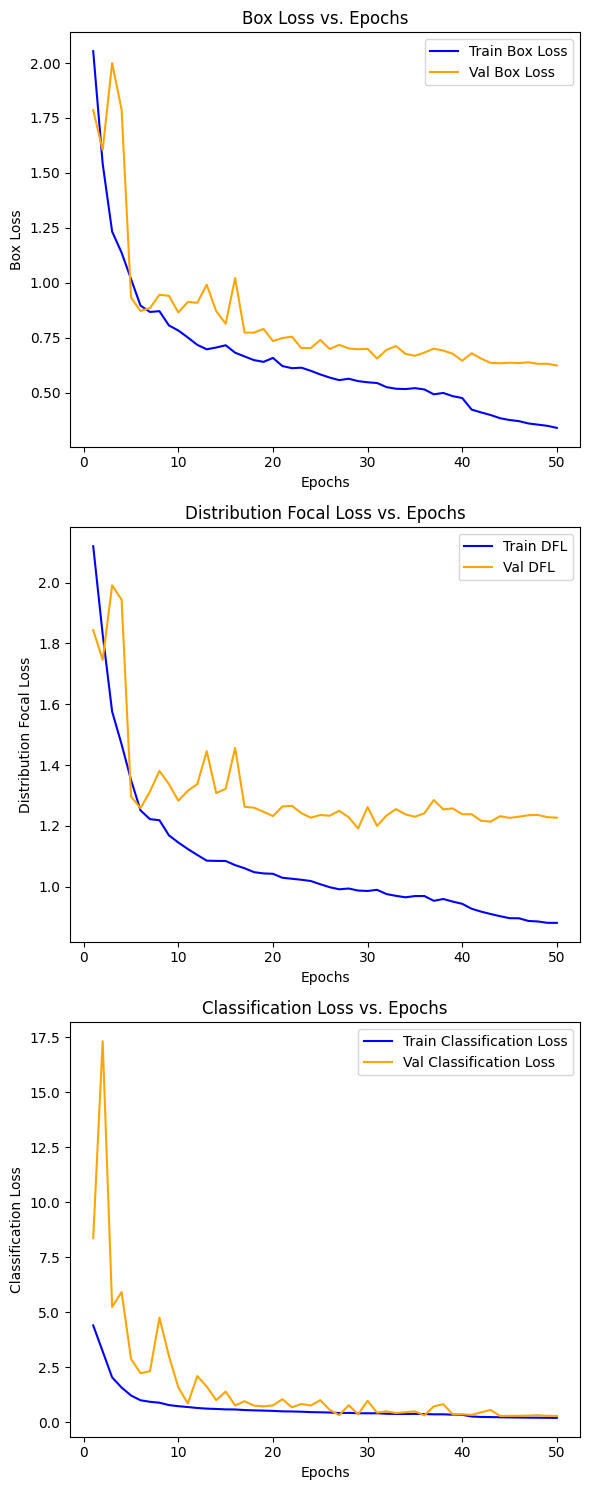

In [ ]:
helpers.plot_losses(results_df_lwir)

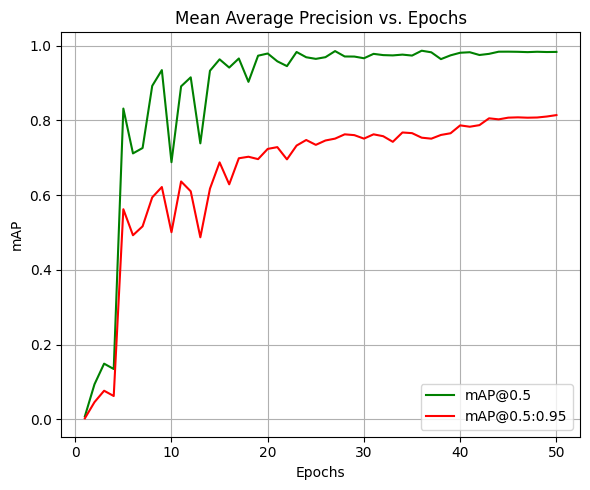

In [ ]:
helpers.plot_map(results_df_lwir)

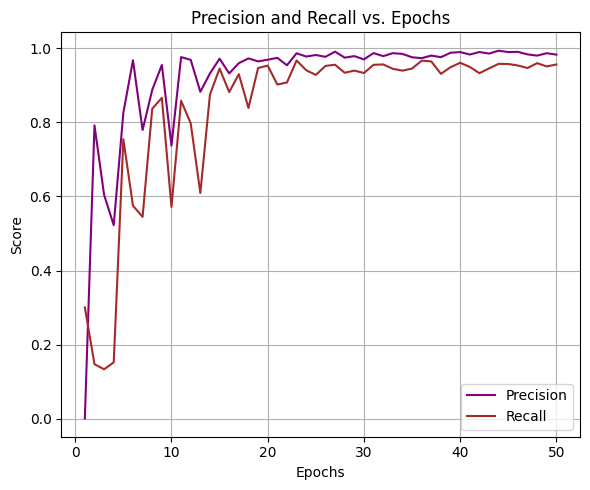

In [ ]:
helpers.plot_precision_recall(results_df_lwir)

In [18]:
# Evaluation on the test set
metrics_lwir = model.val(data=data_yaml_lwir, split='test', imgsz=640, conf=0.25)

print(f"Mean Precision:        {metrics_lwir.box.p.mean():.4f}")
print(f"Mean Recall:           {metrics_lwir.box.r.mean():.4f}")
print(f"Mean mAP@0.5:          {metrics_lwir.box.map50.mean():.4f}")
print(f"Mean mAP@0.5:0.95:     {metrics_lwir.box.map.mean():.4f}")

Ultralytics 8.3.198 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1576.1±1028.5 MB/s, size: 85.1 KB)
val: Scanning /content/dataset/test/labels... 1149 images, 149 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1149/1149 2.6Kit/s 0.4s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 7.8it/s 9.2s
                   all       1149       1765      0.947      0.978      0.961      0.798
                 other        700        760      0.997      0.902      0.951      0.867
                 PFM-1        638        683      0.991      0.975      0.988      0.855
                   PMN        151        151      0.969      0.993      0.994      0.853
                    M6         79         79      0.725          1      0.845 

Confusion Matrix:
[[        687           0           0           0           0           0           1]
 [          0         668           0           0           0           0           7]
 [          0           0         150           0           0           0           9]
 [          0           0           0          79           0           0          30]
 [          0           0           0           0          61           0           0]
 [          0           0           0           0           0          31           0]
 [         73          15           1           0           0           0           0]]


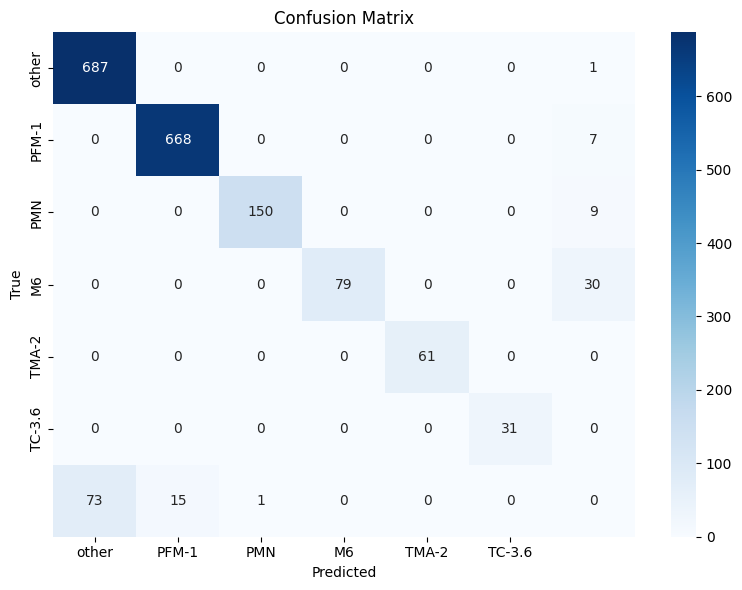

In [ ]:
helpers.plot_confusion_matrix(metrics_lwir)
